In [13]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from collections import Counter
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, roc_curve, f1_score,
    balanced_accuracy_score, classification_report, confusion_matrix,
)

from utilz.Dataset import load_dataset
from utilz.constans import DISEASE, HEALTHY
meta_path = r"../data/samples_pancreatic.xlsx"
data_path = r"../data/counts_pancreatic.csv"
ds = load_dataset(data_path, meta_path, label_col="Group")

TEST_SIZE = 0.2
VALID_SIZE = 0.2
ANOVA_PERCENTILE = 60
MEAN_PERCENTILE = 20

ds.y = ds.y.replace({DISEASE: HEALTHY})

le = LabelEncoder()
y_encoded = pd.Series(le.fit_transform(ds.y), index=ds.y.index)
X_train, X_test, _, y_train, y_test, _ = (
    ds.get_train_test_valid_split(ds.X, y_encoded, test_size=TEST_SIZE, valid_size=VALID_SIZE)
)
print("Class mapping:")
print(f"{le.classes_[0]} -> {le.transform(le.classes_)[0]}")
print(f"{le.classes_[1]} -> {le.transform(le.classes_)[1]}")

print("Encoded label distribution:")
print(y_encoded.value_counts().sort_index())

[INFO] skipped 1973 probs due to missing metadata
Dropping inconsistent sample:
                        Sex   Age                Group   Institution  \
Vumc-ChronPan-29-TR1045   M  58.0  Pancreatic diseases  Institute 13   

                         Lib.size Stage RealLocation    Mode  CA125  \
Vumc-ChronPan-29-TR1045   1493422    IV         VUMC  Single    NaN   

                         Platelets Histology   Datasplit Gdansk_sample_name  \
Vumc-ChronPan-29-TR1045        NaN       NaN  Validation                NaN   

                        StageFull  LeukoMichal      PTPRC  
Vumc-ChronPan-29-TR1045        IV  7726.550165  97.092449  
[INFO] 7 samples with unique strata added to train set
[INFO] 4 samples with unique strata (2nd split) added to train set

[ASSERTION PASSED] No leakage detected between splits.
Class mapping:
Asymptomatic controls -> 0
Pancreatic cancer -> 1
Encoded label distribution:
0    459
1    124
Name: count, dtype: int64


In [14]:
folds = ds.get_stratified_kfold(X_train, y_train, n_splits=5, random_state=2137)

gene_selection_counts = Counter()
fold_coef_records = []

shap_ranking = pd.read_csv("top100_shap_ranking.csv")
candidate_genes = shap_ranking["gene"].tolist()

candidate_genes = [g for g in candidate_genes if g in X_train.columns]
X_cand = X_train[candidate_genes]


for fold_idx, (train_idx, val_idx) in enumerate(folds):
    X_fold_train = X_cand.iloc[train_idx]
    y_fold_train = y_train.iloc[train_idx]
    X_fold_test = X_cand.iloc[val_idx]
    y_fold_test = y_train.iloc[val_idx]

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            penalty="elasticnet",
            solver="saga",
            C=1,
            l1_ratio=0.5,
            class_weight="balanced",
            max_iter=5000,
            random_state=44
        ))
    ])
    pipe.fit(X_fold_train, y_fold_train)
    pipe.predict(X_fold_test)
    
    print("AUC:", roc_auc_score(y_fold_test, pipe.predict_proba(X_fold_test)[:, 1]))

    coefs = pipe.named_steps["clf"].coef_[0]
    selected = [g for g, c in zip(candidate_genes, coefs) if c != 0.0]

    gene_selection_counts.update(selected)
    fold_coef_records.append(
        pd.Series(np.abs(coefs), index=candidate_genes, name=f"fold_{fold_idx}")
    )
    print(f"  Fold {fold_idx}: {len(selected)} genów z niezerowym beta")
# Raport stabilności
coef_df = pd.DataFrame(fold_coef_records).T
stability = pd.DataFrame({
    "folds_selected": pd.Series(gene_selection_counts),
    "mean_abs_coef":  coef_df.mean(axis=1),
    "std_abs_coef":   coef_df.std(axis=1),
}).fillna(0).sort_values(["folds_selected", "mean_abs_coef"], ascending=[False, False])

print("\n--- Stabilność genów ---")
print(stability.head(20).to_string())
print(f"\nGeny w 5/5 foldach: {(stability['folds_selected'] == 5).sum()}")
print(f"Geny w 4/5 foldach: {(stability['folds_selected'] == 4).sum()}")

# Finalne top 10
top10_genes = stability.head(10).index.tolist()
print(f"\nFinalne top 10 genów:\n{top10_genes}")


[INFO] Generated 5 folds. Remainder (7) added to training set in each fold.
AUC: 0.9948979591836735
  Fold 0: 87 genów z niezerowym beta
AUC: 0.9818181818181817
  Fold 1: 88 genów z niezerowym beta
AUC: 0.9895833333333334
  Fold 2: 87 genów z niezerowym beta
AUC: 0.9700332963374029
  Fold 3: 91 genów z niezerowym beta
AUC: 0.9818181818181818
  Fold 4: 82 genów z niezerowym beta

--- Stabilność genów ---
                 folds_selected  mean_abs_coef  std_abs_coef
ENSG00000166428             5.0       1.022105      0.201273
ENSG00000120656             5.0       0.664348      0.131496
ENSG00000177868             5.0       0.651327      0.177015
ENSG00000024422             5.0       0.627484      0.176121
ENSG00000230417             5.0       0.586044      0.148382
ENSG00000225492             5.0       0.564271      0.089942
ENSG00000033170             5.0       0.533262      0.039231
ENSG00000162949             5.0       0.524823      0.123726
ENSG00000119242             5.0       0.5217

Logistic Regression (ElasticNet) — top 10 genów, test set
AUC:               0.602
F1:                0.241
Balanced Accuracy: 0.500

                       precision    recall  f1-score   support

Asymptomatic controls       0.81      0.68      0.74        91
    Pancreatic cancer       0.19      0.32      0.24        22

             accuracy                           0.61       113
            macro avg       0.50      0.50      0.49       113
         weighted avg       0.69      0.61      0.64       113

Confusion matrix:
[[62 29]
 [15  7]]

Współczynniki modelu (top 10):
ENSG00000166428   -1.2398
ENSG00000119242   -0.7846
ENSG00000024422    0.7329
ENSG00000225492    0.6111
ENSG00000120656   -0.6025
ENSG00000033170    0.5425
ENSG00000117009   -0.4067
ENSG00000177868    0.3866
ENSG00000230417    0.3788
ENSG00000162949    0.2910


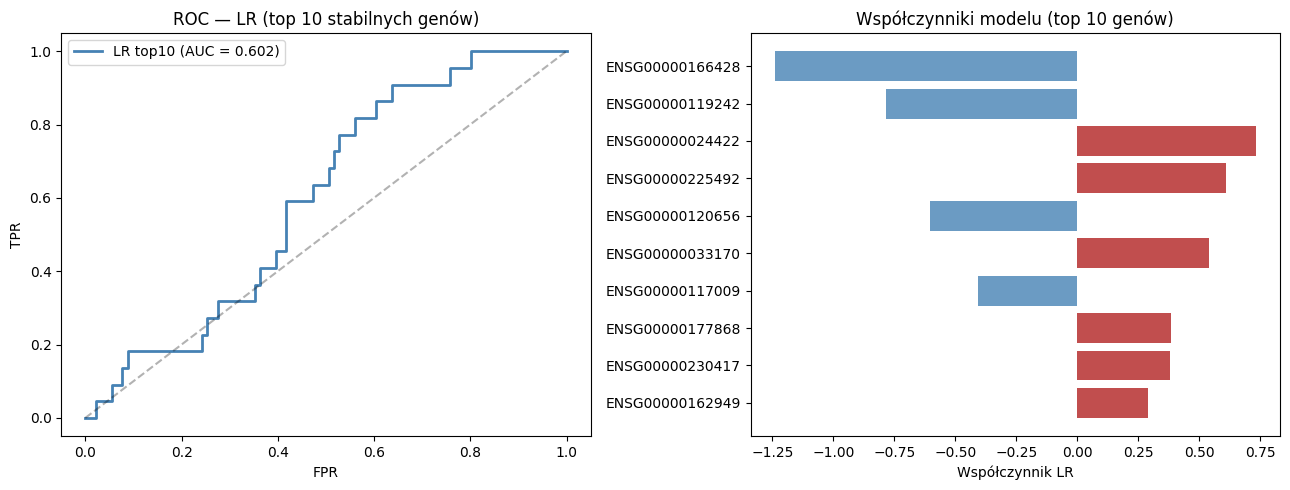

In [5]:
# ── Predykcja na top 10 genach — walidacja na test set ──────────
from sklearn.metrics import (
    roc_auc_score, roc_curve, f1_score,
    balanced_accuracy_score, classification_report, confusion_matrix,
)
from matplotlib import pyplot as plt

# Dane: tylko top 10
X_train_top = X_train[top10_genes]
X_test_top  = X_test[top10_genes]

# Pipeline: scaler + LR
pipe_final = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        C=1,
        l1_ratio=0.5,
        class_weight="balanced",
        max_iter=5000,
        random_state=2137,
    ))
])
pipe_final.fit(X_train_top, y_train)

# Predykcja na test
y_pred  = pipe_final.predict(X_test_top)
y_proba = pipe_final.predict_proba(X_test_top)[:, 1]

# Metryki
auc = roc_auc_score(y_test, y_proba)
f1  = f1_score(y_test, y_pred)
ba  = balanced_accuracy_score(y_test, y_pred)

print(f"{'='*60}")
print(f"Logistic Regression (ElasticNet) — top 10 genów, test set")
print(f"{'='*60}")
print(f"AUC:               {auc:.3f}")
print(f"F1:                {f1:.3f}")
print(f"Balanced Accuracy: {ba:.3f}")
print(f"\n{classification_report(y_test, y_pred, target_names=le.classes_)}")
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

# Współczynniki modelu
coefs = pd.Series(
    pipe_final.named_steps["clf"].coef_[0],
    index=top10_genes
).sort_values(key=abs, ascending=False)
print("\nWspółczynniki modelu (top 10):")
print(coefs.to_string(float_format="%.4f"))

# ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(fpr, tpr, color='steelblue', lw=2, label=f"LR top10 (AUC = {auc:.3f})")
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[0].set_xlabel("FPR")
axes[0].set_ylabel("TPR")
axes[0].set_title("ROC — LR (top 10 stabilnych genów)")
axes[0].legend()

# Barplot współczynników
colors = ['firebrick' if c > 0 else 'steelblue' for c in coefs.values]
axes[1].barh(coefs.index, coefs.values, color=colors, alpha=0.8)
axes[1].set_xlabel("Współczynnik LR")
axes[1].set_title("Współczynniki modelu (top 10 genów)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()